# 03 - Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the cleaned Global Superstore dataset in order to identify the main factors influencing sales and profitability.

This analysis focuses on business questions related to:

- sales performance
- profitability
- products
- customers
- regions
- discounts
- shipping costs

The goal is to discover patterns and insights that will later support SQL analysis, dashboard design, and business recommendations.


## How to Read This Notebook

Each section follows the same logic:

1. **Business question**: what decision or issue are we trying to understand?
2. **Analysis**: what data do we calculate or visualize?
3. **Observation guide**: how should the result be interpreted?

At this stage, the goal is not to write final recommendations yet. The goal is to identify where the business should investigate further.


## 1. Notebook Setup

This section imports the libraries used in the analysis and defines helper functions to make the notebook easier to read.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


In [2]:
def format_currency(value):
    """Format a number as currency for display."""
    if pd.isna(value):
        return "N/A"
    return f"${value:,.0f}"


def format_percent(value):
    """Format a decimal number as a percentage for display."""
    if pd.isna(value):
        return "N/A"
    return f"{value:.2%}"


def aggregate_performance(data, group_cols):
    """Aggregate common business KPIs by one or several dimensions."""
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    grouped = (
        data.groupby(group_cols, as_index=False)
        .agg(
            sales=("sales", "sum"),
            profit=("profit", "sum"),
            quantity=("quantity", "sum"),
            orders=("order_id", "nunique"),
            customers=("customer_id", "nunique")
        )
    )

    grouped["profit_margin"] = np.where(
        grouped["sales"] != 0,
        grouped["profit"] / grouped["sales"],
        np.nan
    )

    return grouped


def plot_bar(data, x, y, title, xlabel, ylabel, rotation=45):
    """Create a simple bar chart."""
    plt.figure(figsize=(10, 6))
    plt.bar(data[x].astype(str), data[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def plot_horizontal_bar(data, x, y, title, xlabel, ylabel):
    """Create a simple horizontal bar chart."""
    plt.figure(figsize=(10, 6))
    plt.barh(data[y].astype(str), data[x])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_line(data, x, y, title, xlabel, ylabel):
    """Create a simple line chart."""
    plt.figure(figsize=(12, 6))
    plt.plot(data[x], data[y], marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_scatter(data, x, y, title, xlabel, ylabel):
    """Create a simple scatter plot."""
    plt.figure(figsize=(10, 6))
    plt.scatter(data[x], data[y], alpha=0.4)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


## 2. Load the Cleaned Dataset

From this notebook onward, the analysis uses the cleaned dataset created in `02_data_cleaning.ipynb`.

The raw dataset should no longer be used directly for analysis.


In [3]:
df = pd.read_csv("cleaned_superstore.csv", parse_dates=["order_date", "ship_date"])

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())


Rows: 37,670
Columns: 36


,row_id,order_id,order_date,ship_date,order_year,order_month,order_month_name,order_quarter,order_year_month,order_week,order_priority,customer_id,customer_name,segment,product_id,product_name,category,sub_category,country,state,city,region,market,market_group,sales,quantity,discount,profit,shipping_cost,ship_mode,shipping_delay_days,profit_margin,profit_status,discount_band,shipping_cost_ratio,order_size
0,36624,CA-2011-130813,2011-01-07,2011-01-09,2011,1,January,Q1,2011-01,2,High,LS-172304,Lycoris Saunders,Consumer,OFF-PA-10002005,Xerox 225,Office Supplies,Paper,United States,California,Los Angeles,West,US,North America,19.00,3.00,0.00,9.33,4.37,Second Class,2.00,0.49,Profitable,No discount,0.23,Medium
1,37033,CA-2011-148614,2011-01-21,2011-01-26,2011,1,January,Q1,2011-01,4,Medium,MV-174854,Mark Van Huff,Consumer,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",Office Supplies,Paper,United States,California,Los Angeles,West,US,North America,19.00,2.00,0.00,9.29,0.94,Standard Class,5.00,0.49,Profitable,No discount,0.05,Small
2,31468,CA-2011-118962,2011-08-05,2011-08-09,2011,8,August,Q3,2011-08,32,Medium,CS-121304,Chad Sievert,Consumer,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",Office Supplies,Paper,United States,California,Los Angeles,West,US,North America,21.00,3.00,0.00,9.84,1.81,Standard Class,4.00,0.47,Profitable,No discount,0.09,Medium
3,31469,CA-2011-118962,2011-08-05,2011-08-09,2011,8,August,Q3,2011-08,32,Medium,CS-121304,Chad Sievert,Consumer,OFF-PA-10001144,Xerox 1913,Office Supplies,Paper,United States,California,Los Angeles,West,US,North America,111.00,2.00,0.00,53.26,4.59,Standard Class,4.00,0.48,Profitable,No discount,0.04,Small
4,32440,CA-2011-146969,2011-09-29,2011-10-03,2011,9,September,Q3,2011-09,40,High,AP-109154,Arthur Prichep,Consumer,OFF-PA-10002105,Xerox 223,Office Supplies,Paper,United States,California,Los Angeles,West,US,North America,6.00,1.00,0.00,3.11,1.32,Standard Class,4.00,0.52,Profitable,No discount,0.22,Small


In [4]:
required_columns = [
    "order_id", "order_date", "ship_date", "customer_id", "product_id",
    "sales", "profit", "quantity", "discount", "shipping_cost",
    "category", "sub_category", "segment", "market", "region", "country",
    "ship_mode", "order_priority"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
else:
    print("All required columns are available.")


All required columns are available.


## 3. Quick Data Sanity Check

Before starting the exploratory analysis, the cleaned dataset is checked again to confirm that the main quality indicators are still valid.


In [5]:
sanity_check = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Missing values",
        "Duplicated rows",
        "Unique orders",
        "Unique customers",
        "Unique products",
        "Date range",
        "Ship date before order date"
    ],
    "Result": [
        f"{df.shape[0]:,}",
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        f"{df['order_id'].nunique():,}",
        f"{df['customer_id'].nunique():,}",
        f"{df['product_id'].nunique():,}",
        f"{df['order_date'].min().date()} to {df['order_date'].max().date()}",
        (df["ship_date"] < df["order_date"]).sum()
    ]
})

sanity_check


,Check,Result
0,Rows,"37,670"
1,Columns,36
2,Missing values,18
3,Duplicated rows,0
4,Unique orders,"19,000"
5,Unique customers,"4,798"
6,Unique products,"9,644"
7,Date range,2011-01-01 to 2014-12-31
8,Ship date before order date,0


## 4. Business KPI Overview

### Business Question

**What is the overall business performance of Nova Retail?**

This section calculates the main KPIs that will be used throughout the project.


In [6]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
profit_margin = total_profit / total_sales if total_sales != 0 else np.nan
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_products = df["product_id"].nunique()
total_countries = df["country"].nunique()
average_order_value = total_sales / total_orders if total_orders != 0 else np.nan
average_profit_per_order = total_profit / total_orders if total_orders != 0 else np.nan
loss_making_rows = (df["profit"] < 0).sum()
profitable_rows = (df["profit"] > 0).sum()
loss_making_share = loss_making_rows / len(df) if len(df) != 0 else np.nan

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Countries",
        "Average Order Value",
        "Average Profit per Order",
        "Profitable Rows",
        "Loss-Making Rows",
        "Loss-Making Row Share"
    ],
    "Value": [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        total_products,
        total_countries,
        average_order_value,
        average_profit_per_order,
        profitable_rows,
        loss_making_rows,
        loss_making_share
    ],
    "Formatted Value": [
        format_currency(total_sales),
        format_currency(total_profit),
        format_percent(profit_margin),
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"{total_countries:,}",
        format_currency(average_order_value),
        format_currency(average_profit_per_order),
        f"{profitable_rows:,}",
        f"{loss_making_rows:,}",
        format_percent(loss_making_share)
    ]
})

kpi_summary


,KPI,Value,Formatted Value
0,Total Sales,"9,089,599.00","$9,089,599"
1,Total Profit,"1,524,448.16","$1,524,448"
2,Profit Margin,0.17,16.77%
3,Total Orders,"19,000.00","19,000"
4,Total Customers,"4,798.00","4,798"
5,Total Products,"9,644.00","9,644"
6,Total Countries,146.00,146
7,Average Order Value,478.40,$478
8,Average Profit per Order,80.23,$80
9,Profitable Rows,"31,095.00","31,095"


### Observation Guide

Focus on the relationship between total sales, total profit, and profit margin.

If sales are high but profit margin is low, the company may be selling a lot without generating enough value.


### Key Observation

Nova Retail is profitable overall, with a total profit of approximately **$1.47M** and an overall profit margin of **11.61%**.

However, **24.46% of order lines are loss-making**. This means that the company is generating profit at the global level, but a significant portion of transactions reduces overall performance.

This confirms the main business problem of the project: **increasing sales alone is not enough**. The company needs to understand which products, discounts, regions, or operational factors are causing losses.

## 5. Sales and Profit Trends Over Time

### Business Question

**Are sales and profit moving in the same direction over time?**

This section analyzes yearly and monthly trends to understand whether revenue growth is aligned with profitability growth.


In [7]:
yearly_performance = aggregate_performance(df, "order_year").sort_values("order_year")
yearly_performance["sales_growth"] = yearly_performance["sales"].pct_change()
yearly_performance["profit_growth"] = yearly_performance["profit"].pct_change()

yearly_performance_display = yearly_performance.copy()
yearly_performance_display["sales"] = yearly_performance_display["sales"].map(format_currency)
yearly_performance_display["profit"] = yearly_performance_display["profit"].map(format_currency)
yearly_performance_display["profit_margin"] = yearly_performance_display["profit_margin"].map(format_percent)
yearly_performance_display["sales_growth"] = yearly_performance_display["sales_growth"].map(format_percent)
yearly_performance_display["profit_growth"] = yearly_performance_display["profit_growth"].map(format_percent)

yearly_performance_display


,order_year,sales,profit,quantity,orders,customers,profit_margin,sales_growth,profit_growth
0,2011,"$1,601,272","$260,348","22,586.00",3353,2428,16.26%,N/A,N/A
1,2012,"$1,936,255","$316,935","27,665.00",4086,2714,16.37%,20.92%,21.74%
2,2013,"$2,466,163","$424,159","35,024.00",5129,3137,17.20%,27.37%,33.83%
3,2014,"$3,085,909","$523,005","43,496.00",6432,3540,16.95%,25.13%,23.30%


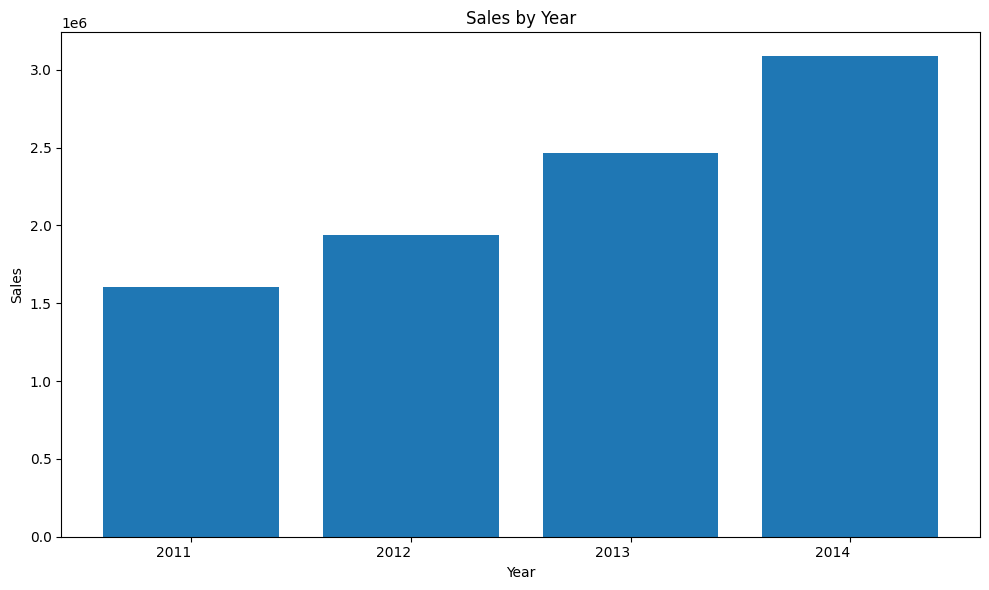

In [8]:
plot_bar(
    yearly_performance,
    x="order_year",
    y="sales",
    title="Sales by Year",
    xlabel="Year",
    ylabel="Sales",
    rotation=0
)


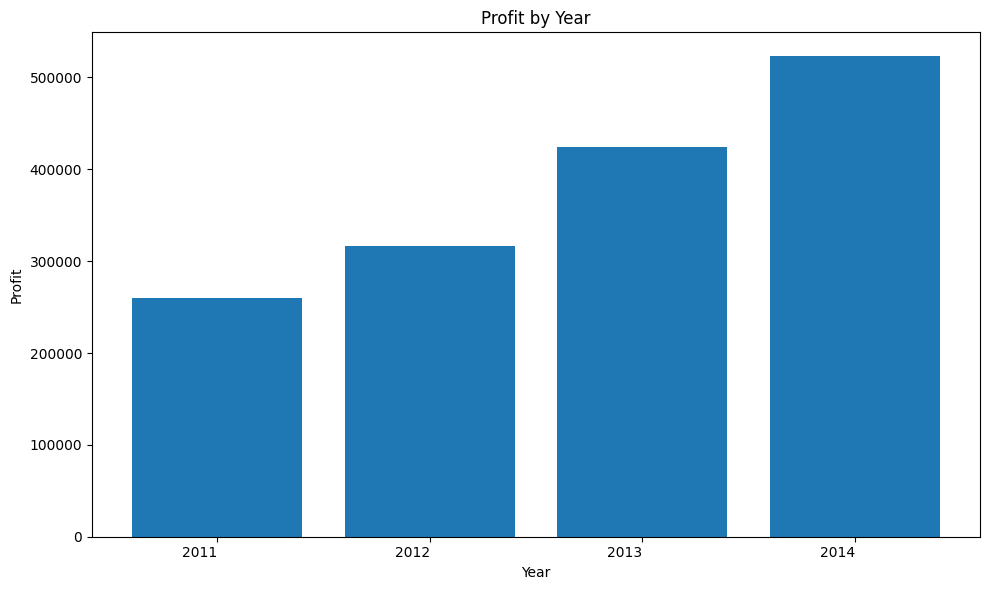

In [9]:
plot_bar(
    yearly_performance,
    x="order_year",
    y="profit",
    title="Profit by Year",
    xlabel="Year",
    ylabel="Profit",
    rotation=0
)


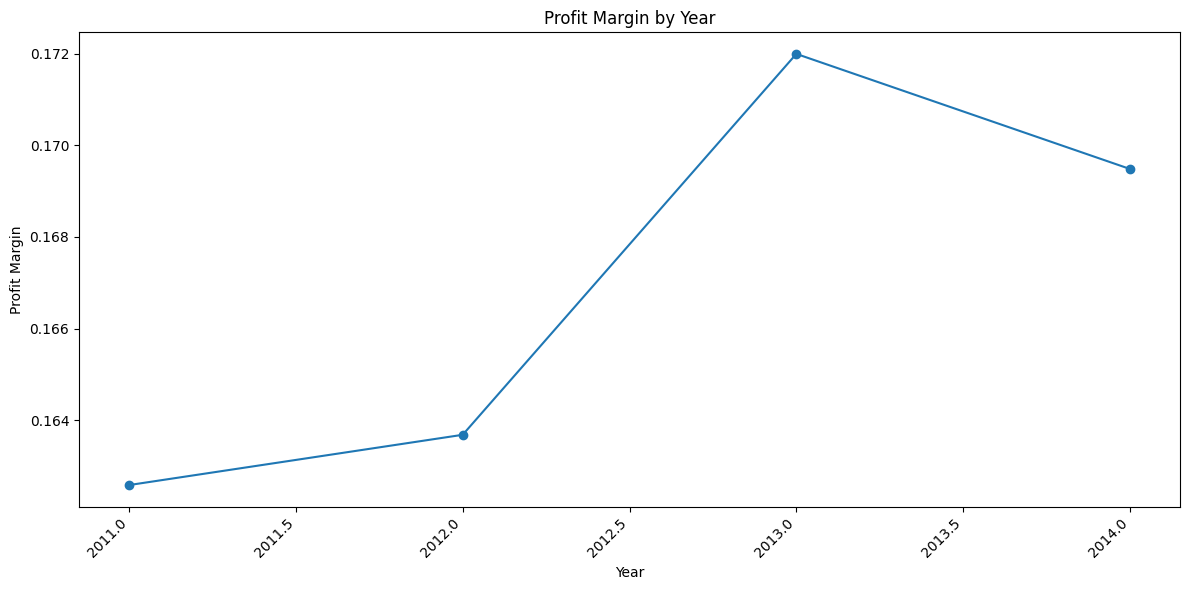

In [10]:
plot_line(
    yearly_performance,
    x="order_year",
    y="profit_margin",
    title="Profit Margin by Year",
    xlabel="Year",
    ylabel="Profit Margin"
)


In [11]:
monthly_performance = aggregate_performance(df, "order_year_month")
monthly_performance["period"] = pd.PeriodIndex(monthly_performance["order_year_month"], freq="M").to_timestamp()
monthly_performance = monthly_performance.sort_values("period")

monthly_performance.head()


,order_year_month,sales,profit,quantity,orders,customers,profit_margin,period
0,2011-01,"80,647.00","13,473.97","1,109.00",163,159,0.17,2011-01-01
1,2011-02,"80,197.00","15,105.37","1,021.00",147,145,0.19,2011-02-01
2,2011-03,"83,625.00","17,949.70","1,187.00",193,189,0.21,2011-03-01
3,2011-04,"82,753.00","10,930.80","1,492.00",208,202,0.13,2011-04-01
4,2011-05,"112,234.00","14,551.74","1,465.00",224,220,0.13,2011-05-01


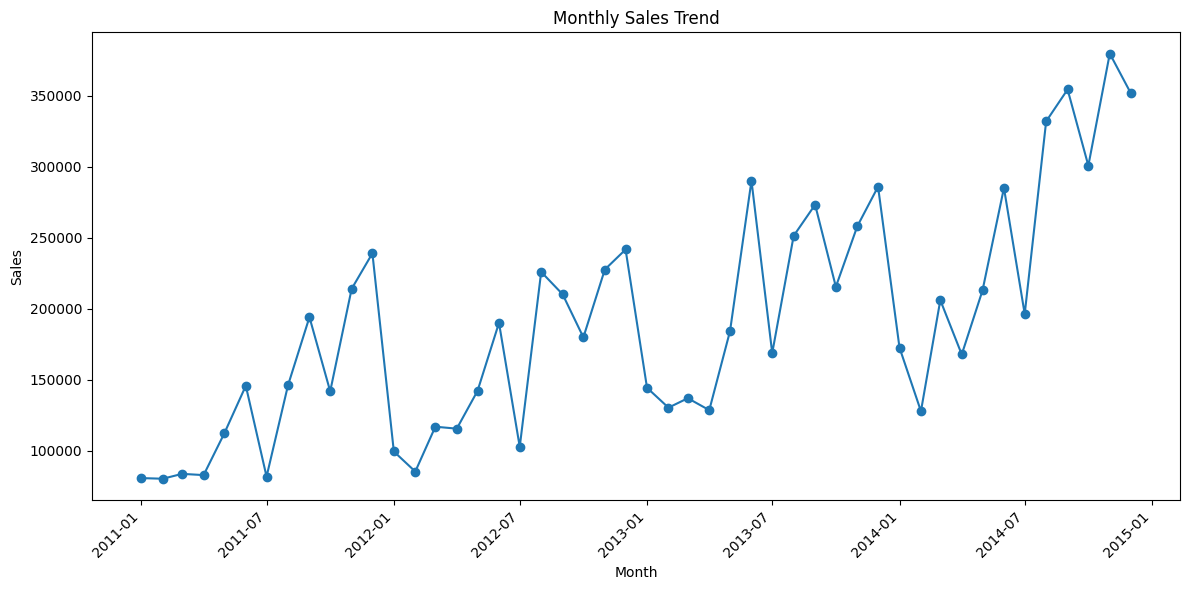

In [12]:
plot_line(
    monthly_performance,
    x="period",
    y="sales",
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Sales"
)


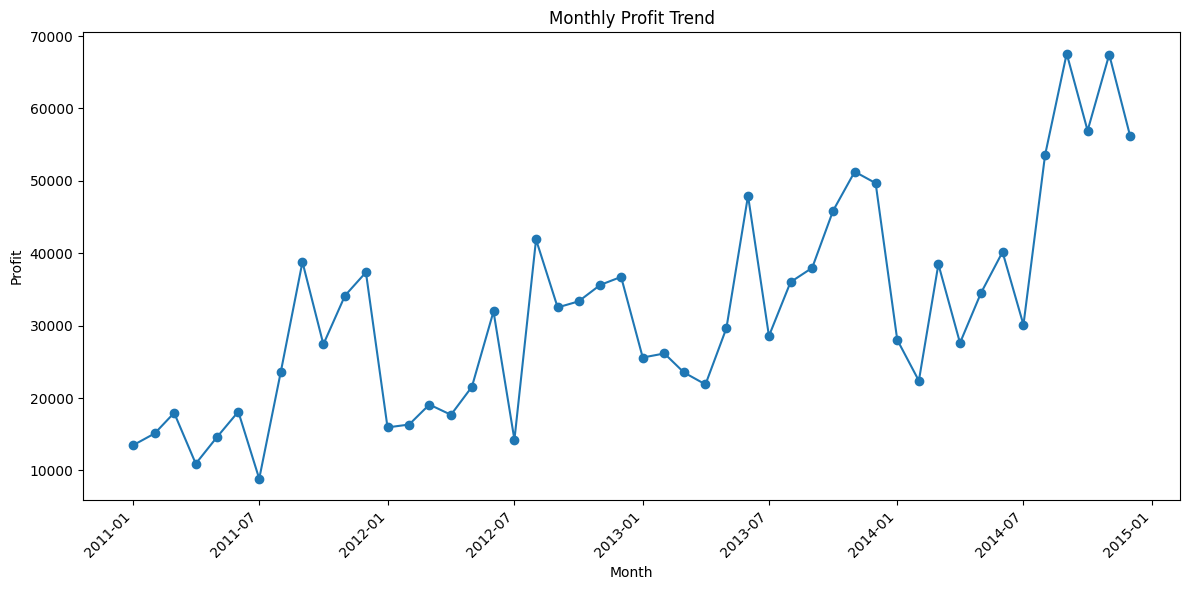

In [13]:
plot_line(
    monthly_performance,
    x="period",
    y="profit",
    title="Monthly Profit Trend",
    xlabel="Month",
    ylabel="Profit"
)


### Observation Guide

Look for periods where sales increase but profit does not increase at the same pace.

Those periods may reveal issues related to discounts, product mix, shipping costs, or regional performance.


### Key Observation

Sales and profit both increased between **2011 and 2014**, which shows that the business is growing.

However, in **2014**, sales growth was stronger than profit growth. Sales increased by **26.25%**, while profit increased by **23.89%**.

This suggests that the company may be growing, but not every additional sale contributes equally to profitability. The next sections will investigate whether this difference is linked to products, discounts, customer segments, markets, or shipping costs.

## 6. Category and Sub-Category Performance

### Business Question

**Which product categories generate the most business value?**

This section compares sales, profit, and profit margin across product categories and sub-categories.


In [14]:
category_performance = aggregate_performance(df, "category").sort_values("profit", ascending=False)
category_performance_display = category_performance.copy()
category_performance_display["sales"] = category_performance_display["sales"].map(format_currency)
category_performance_display["profit"] = category_performance_display["profit"].map(format_currency)
category_performance_display["profit_margin"] = category_performance_display["profit_margin"].map(format_percent)

category_performance_display


,category,sales,profit,quantity,orders,customers,profit_margin
2,Technology,"$3,424,238","$627,664","24,345.00",5937,3345,18.33%
1,Office Supplies,"$2,948,808","$530,452","81,806.00",14741,4643,17.99%
0,Furniture,"$2,716,553","$366,332","22,620.00",5502,3158,13.49%


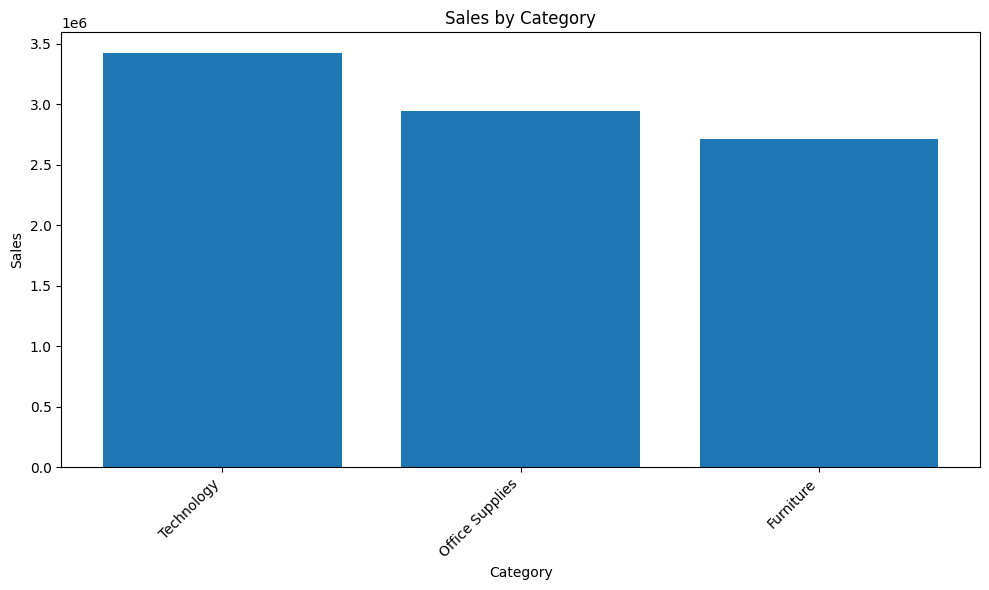

In [15]:
plot_bar(
    category_performance.sort_values("sales", ascending=False),
    x="category",
    y="sales",
    title="Sales by Category",
    xlabel="Category",
    ylabel="Sales"
)


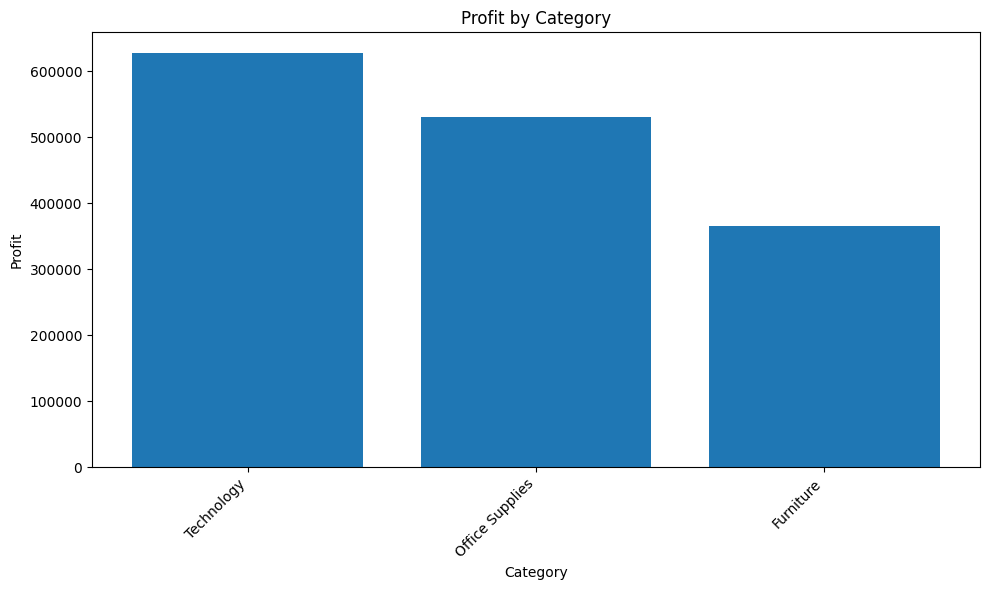

In [16]:
plot_bar(
    category_performance.sort_values("profit", ascending=False),
    x="category",
    y="profit",
    title="Profit by Category",
    xlabel="Category",
    ylabel="Profit"
)


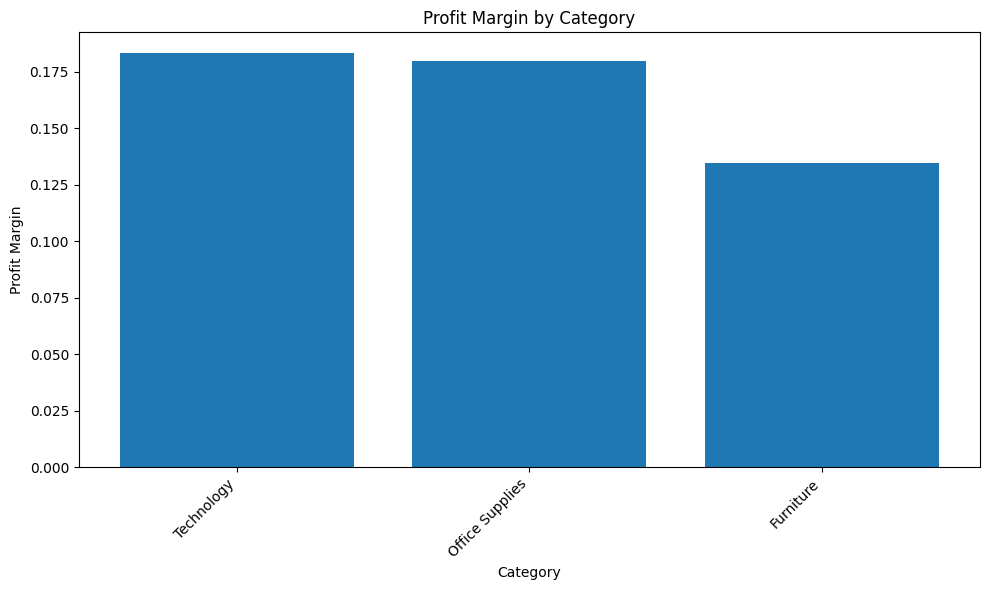

In [17]:
plot_bar(
    category_performance.sort_values("profit_margin", ascending=False),
    x="category",
    y="profit_margin",
    title="Profit Margin by Category",
    xlabel="Category",
    ylabel="Profit Margin"
)


In [18]:
sub_category_performance = aggregate_performance(df, ["category", "sub_category"])
sub_category_performance = sub_category_performance.sort_values("profit", ascending=False)

sub_category_display = sub_category_performance.copy()
sub_category_display["sales"] = sub_category_display["sales"].map(format_currency)
sub_category_display["profit"] = sub_category_display["profit"].map(format_currency)
sub_category_display["profit_margin"] = sub_category_display["profit_margin"].map(format_percent)

sub_category_display


,category,sub_category,sales,profit,quantity,orders,customers,profit_margin
15,Technology,Copiers,"$1,038,771","$208,208","4,967.00",1449,1216,20.04%
17,Technology,Phones,"$1,236,339","$200,805","7,621.00",2052,1655,16.24%
0,Furniture,Bookcases,"$1,049,880","$176,165","5,686.00",1604,1308,16.78%
4,Office Supplies,Appliances,"$782,618","$135,818","4,407.00",1254,1112,17.35%
14,Technology,Accessories,"$608,723","$129,560","8,199.00",2189,1708,21.28%
1,Furniture,Chairs,"$912,644","$128,917","7,443.00",1966,1513,14.13%
12,Office Supplies,Storage,"$868,568","$111,752","12,764.00",3496,2498,12.87%
16,Technology,Machines,"$540,405","$89,091","3,558.00",1023,912,16.49%
6,Office Supplies,Binders,"$308,053","$83,239","14,449.00",3762,2532,27.02%
5,Office Supplies,Art,"$327,763","$61,908","13,369.00",3583,2473,18.89%


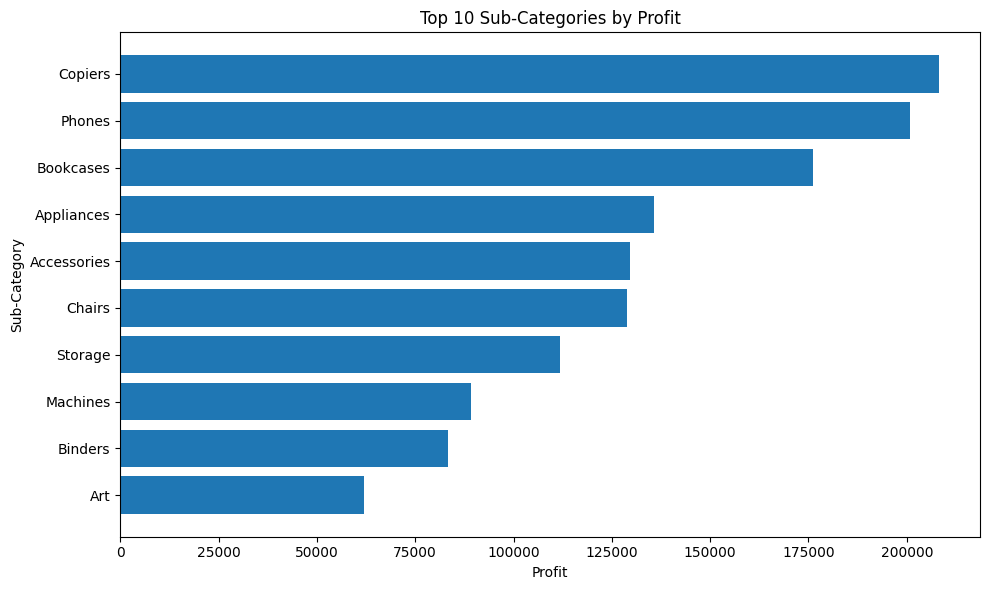

In [19]:
top_sub_categories = sub_category_performance.sort_values("profit", ascending=False).head(10)

plot_horizontal_bar(
    top_sub_categories.sort_values("profit"),
    x="profit",
    y="sub_category",
    title="Top 10 Sub-Categories by Profit",
    xlabel="Profit",
    ylabel="Sub-Category"
)


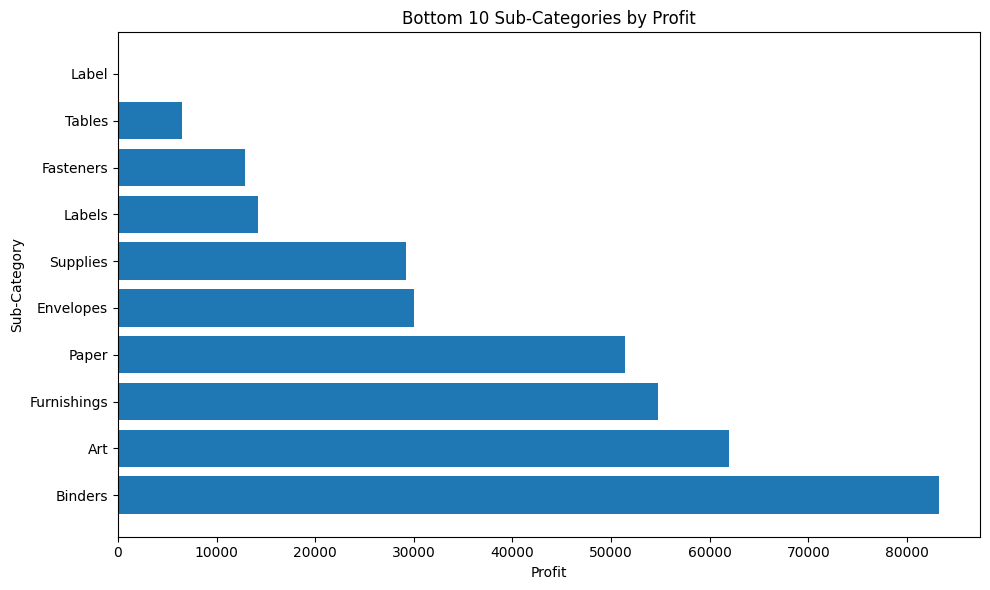

In [20]:
bottom_sub_categories = sub_category_performance.sort_values("profit", ascending=True).head(10)

plot_horizontal_bar(
    bottom_sub_categories.sort_values("profit", ascending=False),
    x="profit",
    y="sub_category",
    title="Bottom 10 Sub-Categories by Profit",
    xlabel="Profit",
    ylabel="Sub-Category"
)


### Observation Guide

A category with high sales but low profit margin may require deeper investigation.

A sub-category with negative profit may be affected by discounts, shipping costs, or weak pricing strategy.


### Key Observation

Most sub-categories are profitable, but **Tables** stand out as a major loss-making sub-category.

Although Tables generated more than **$757K in sales**, they produced a loss of approximately **$64K**, with a profit margin of **-8.47%**.

This is an important finding because it shows that high revenue does not always mean strong business performance. Tables should be investigated further, especially in relation to discounts, shipping costs, and markets.

## 7. Product Performance Analysis

### Business Question

**Do all products contribute positively to profitability?**

This section identifies products that generate high sales, high profit, or losses.


In [21]:
product_performance = aggregate_performance(
    df,
    ["product_id", "product_name", "category", "sub_category"]
)

product_performance = product_performance.sort_values("profit", ascending=False)

product_performance.head()


,product_id,product_name,category,sub_category,sales,profit,quantity,orders,customers,profit_margin
8805,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"42,000.00","20,159.94",12.00,3,3,0.48
2626,OFF-AP-10004512,"Hoover Stove, Red",Office Supplies,Appliances,"21,148.00","10,345.58",38.00,7,7,0.49
9925,TEC-PH-10004823,"Nokia Smart Phone, Full Size",Technology,Phones,"17,968.00","7,453.88",29.00,9,9,0.41
3686,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"13,981.00","6,990.44",11.00,4,4,0.50
710,FUR-CH-10002250,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,"12,835.00","5,403.43",30.00,8,8,0.42


In [22]:
top_products_by_sales = product_performance.sort_values("sales", ascending=False).head(10)

display(top_products_by_sales[[
    "product_name", "category", "sub_category", "sales", "profit", "profit_margin", "orders"
]])


,product_name,category,sub_category,sales,profit,profit_margin,orders
8805,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"42,000.00","20,159.94",0.48,3
2626,"Hoover Stove, Red",Office Supplies,Appliances,"21,148.00","10,345.58",0.49,7
9925,"Nokia Smart Phone, Full Size",Technology,Phones,"17,968.00","7,453.88",0.41,9
9535,"Apple Smart Phone, Full Size",Technology,Phones,"16,997.00","1,676.22",0.10,7
2444,"Hamilton Beach Stove, Silver",Office Supplies,Appliances,"16,293.00","4,844.22",0.30,6
9425,"Samsung Smart Phone, VoIP",Technology,Phones,"16,224.00","5,153.22",0.32,5
9023,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,"15,750.00","5,039.97",0.32,2
437,"Safco Library with Doors, Pine",Furniture,Bookcases,"15,462.00","1,188.84",0.08,7
8415,"Cisco Smart Phone, Full Size",Technology,Phones,"15,178.00","2,982.75",0.20,8
9703,"Samsung Smart Phone, VoIP",Technology,Phones,"15,101.00","1,077.34",0.07,8


In [23]:
top_products_by_profit = product_performance.sort_values("profit", ascending=False).head(10)

display(top_products_by_profit[[
    "product_name", "category", "sub_category", "sales", "profit", "profit_margin", "orders"
]])


,product_name,category,sub_category,sales,profit,profit_margin,orders
8805,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"42,000.00","20,159.94",0.48,3
2626,"Hoover Stove, Red",Office Supplies,Appliances,"21,148.00","10,345.58",0.49,7
9925,"Nokia Smart Phone, Full Size",Technology,Phones,"17,968.00","7,453.88",0.41,9
3686,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"13,981.00","6,990.44",0.50,4
710,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,"12,835.00","5,403.43",0.42,8
9425,"Samsung Smart Phone, VoIP",Technology,Phones,"16,224.00","5,153.22",0.32,5
9023,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,"15,750.00","5,039.97",0.32,2
3340,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,"9,893.00","4,946.37",0.50,1
2444,"Hamilton Beach Stove, Silver",Office Supplies,Appliances,"16,293.00","4,844.22",0.30,6
3404,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,"9,450.00","4,630.48",0.49,1


In [24]:
loss_making_products = product_performance.sort_values("profit", ascending=True).head(10)

display(loss_making_products[[
    "product_name", "category", "sub_category", "sales", "profit", "profit_margin", "orders"
]])


,product_name,category,sub_category,sales,profit,profit_margin,orders
9320,"Motorola Smart Phone, Cordless",Technology,Phones,"10,350.00","-3,998.68",-0.39,7
9722,"Apple Smart Phone, Full Size",Technology,Phones,"3,499.00","-3,009.43",-0.86,1
637,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,"3,132.00","-2,954.44",-0.94,2
28,"Barricks Conference Table, Rectangular",Furniture,Tables,"3,076.00","-2,460.81",-0.80,2
1954,"Hon Conference Table, Rectangular",Furniture,Tables,"1,287.00","-2,380.35",-1.85,1
2015,"Barricks Conference Table, Adjustable Height",Furniture,Tables,"3,728.00","-2,082.39",-0.56,2
9012,"Okidata Inkjet, Wireless",Technology,Machines,"3,235.00","-2,052.23",-0.63,4
1995,"Barricks Computer Table, Fully Assembled",Furniture,Tables,"3,633.00","-1,965.55",-0.54,3
2052,"Bevis Conference Table, Fully Assembled",Furniture,Tables,555.00,"-1,924.54",-3.47,1
2383,"Hoover Stove, White",Office Supplies,Appliances,"8,330.00","-1,898.34",-0.23,5


In [25]:
sales_threshold = product_performance["sales"].quantile(0.75)
median_profit_margin = product_performance["profit_margin"].median()

high_sales_low_margin_products = (
    product_performance[
        (product_performance["sales"] >= sales_threshold) &
        (product_performance["profit_margin"] < median_profit_margin)
    ]
    .sort_values("sales", ascending=False)
    .head(20)
)

high_sales_low_margin_products[[
    "product_name", "category", "sub_category", "sales", "profit", "profit_margin", "orders"
]]


,product_name,category,sub_category,sales,profit,profit_margin,orders
9535,"Apple Smart Phone, Full Size",Technology,Phones,"16,997.00","1,676.22",0.10,7
437,"Safco Library with Doors, Pine",Furniture,Bookcases,"15,462.00","1,188.84",0.08,7
8415,"Cisco Smart Phone, Full Size",Technology,Phones,"15,178.00","2,982.75",0.20,8
9703,"Samsung Smart Phone, VoIP",Technology,Phones,"15,101.00","1,077.34",0.07,8
9911,"Nokia Smart Phone, with Caller ID",Technology,Phones,"15,092.00","2,798.25",0.19,5
9854,"Samsung Smart Phone, Cordless",Technology,Phones,"15,081.00",-370.62,-0.02,9
8414,"Cisco Smart Phone, Cordless",Technology,Phones,"14,071.00","1,563.17",0.11,10
543,"Novimex Executive Leather Armchair, Red",Furniture,Chairs,"13,903.00",-235.28,-0.02,7
7269,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,"13,101.00",524.01,0.04,2
9676,"Motorola Smart Phone, Cordless",Technology,Phones,"12,632.00",-944.91,-0.07,8


In [26]:
positive_profit_products = product_performance[product_performance["profit"] > 0].copy()
positive_profit_products = positive_profit_products.sort_values("profit", ascending=False)
positive_profit_products["cumulative_profit"] = positive_profit_products["profit"].cumsum()
positive_profit_products["cumulative_profit_share"] = (
    positive_profit_products["cumulative_profit"] / positive_profit_products["profit"].sum()
)

products_needed_for_80pct_profit = (
    positive_profit_products[positive_profit_products["cumulative_profit_share"] <= 0.80].shape[0] + 1
)

pareto_summary = pd.DataFrame({
    "Metric": [
        "Total products with positive profit",
        "Products needed to reach around 80% of positive profit",
        "Share of positive-profit products"
    ],
    "Value": [
        positive_profit_products.shape[0],
        products_needed_for_80pct_profit,
        products_needed_for_80pct_profit / positive_profit_products.shape[0]
    ]
})

pareto_summary["Formatted Value"] = [
    f"{positive_profit_products.shape[0]:,}",
    f"{products_needed_for_80pct_profit:,}",
    format_percent(products_needed_for_80pct_profit / positive_profit_products.shape[0])
]

pareto_summary


,Metric,Value,Formatted Value
0,Total products with positive profit,"8,108.00","8,108"
1,Products needed to reach around 80% of positiv...,"2,128.00","2,128"
2,Share of positive-profit products,0.26,26.25%


### Observation Guide

Compare the top products by sales with the top products by profit.

If the lists are very different, it means that revenue alone is not enough to evaluate product performance.


### Key Observation

The product analysis should compare **sales performance** and **profit performance** separately.

A product can generate high revenue but still have a weak profit margin. These products are important to identify because they may look successful from a sales perspective while reducing overall profitability.

This section also helps prepare the future SQL analysis, where products will be ranked by sales, profit, margin, and loss contribution.

### Data Modeling Note for SQL

Before creating SQL tables, it is important to check whether `product_id` can be used as a unique product key.

If the number of unique `product_id` values is different from the number of unique product combinations, then `product_id` alone should not be treated as a perfect product dimension key.

In [27]:
product_identity_check = pd.DataFrame({
    "Metric": [
        "Unique product IDs",
        "Unique product names",
        "Unique product combinations",
        "Rows in product_performance table"
    ],
    "Value": [
        df["product_id"].nunique(),
        df["product_name"].nunique(),
        df[["product_id", "product_name", "category", "sub_category"]].drop_duplicates().shape[0],
        product_performance.shape[0]
    ]
})

product_identity_check

,Metric,Value
0,Unique product IDs,9644
1,Unique product names,3556
2,Unique product combinations,10042
3,Rows in product_performance table,10042


### SQL Preparation Note

For the SQL phase, `product_id` should be handled carefully.

If one product ID is associated with multiple product names or category combinations, the safer approach is to create a product key using the combination:

```text
product_id + product_name + category + sub_category
```

This prevents incorrect joins or duplicated product records in the future relational model.

## 8. Customer and Segment Analysis

### Business Question

**Which customers and customer segments generate the most value?**

This section analyzes profitability by customer segment and identifies high-value or low-value customers.


In [28]:
segment_performance = aggregate_performance(df, "segment").sort_values("profit", ascending=False)
segment_performance_display = segment_performance.copy()
segment_performance_display["sales"] = segment_performance_display["sales"].map(format_currency)
segment_performance_display["profit"] = segment_performance_display["profit"].map(format_currency)
segment_performance_display["profit_margin"] = segment_performance_display["profit_margin"].map(format_percent)

segment_performance_display


,segment,sales,profit,quantity,orders,customers,profit_margin
0,Consumer,"$4,621,460","$784,879","65,536.00",9800,2459,16.98%
1,Corporate,"$2,751,021","$462,537","38,358.00",5767,1438,16.81%
2,Home Office,"$1,717,118","$277,032","24,877.00",3773,901,16.13%


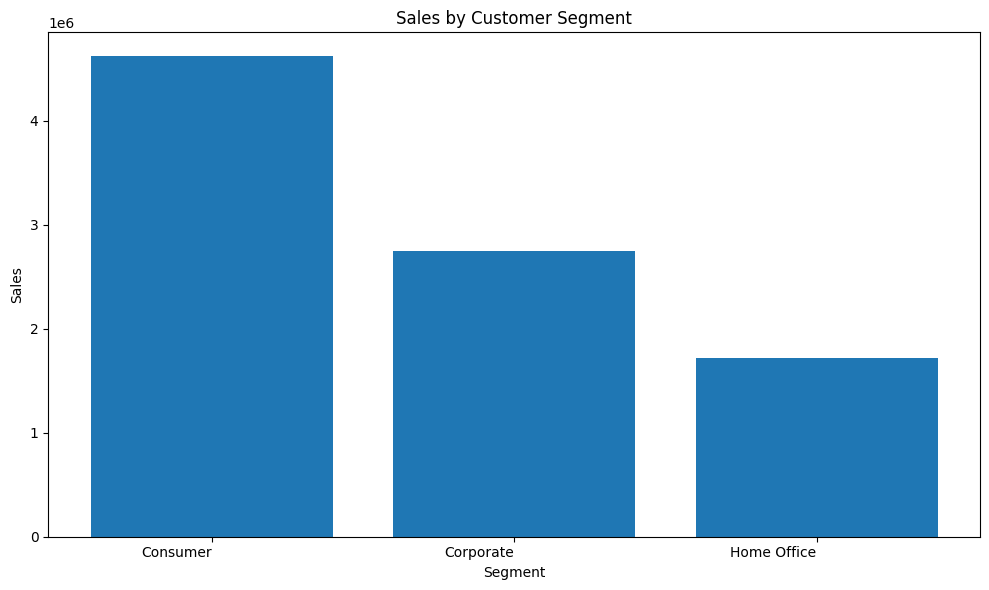

In [29]:
plot_bar(
    segment_performance.sort_values("sales", ascending=False),
    x="segment",
    y="sales",
    title="Sales by Customer Segment",
    xlabel="Segment",
    ylabel="Sales",
    rotation=0
)


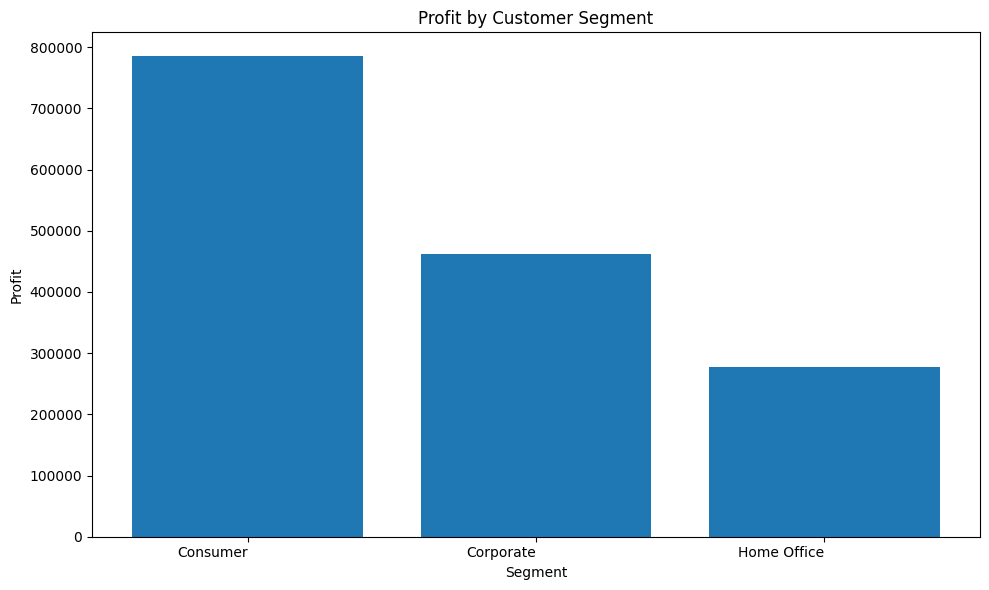

In [30]:
plot_bar(
    segment_performance.sort_values("profit", ascending=False),
    x="segment",
    y="profit",
    title="Profit by Customer Segment",
    xlabel="Segment",
    ylabel="Profit",
    rotation=0
)


In [31]:
customer_performance = aggregate_performance(
    df,
    ["customer_id", "customer_name", "segment"]
)

customer_performance = customer_performance.sort_values("profit", ascending=False)

customer_performance.head()


,customer_id,customer_name,segment,sales,profit,quantity,orders,customers,profit_margin
4497,TC-209804,Tamara Chand,Corporate,"18,919.00","8,987.23",32.00,3,1,0.48
3761,RB-193604,Raymond Buch,Consumer,"14,816.00","6,920.53",49.00,4,1,0.47
4078,SC-200954,Sanjit Chand,Consumer,"12,560.00","5,736.34",60.00,7,1,0.46
37,AB-101054,Adrian Barton,Consumer,"11,963.00","5,675.24",27.00,4,1,0.47
1988,HL-150404,Hunter Lopez,Consumer,"12,859.00","5,617.34",48.00,5,1,0.44


In [32]:
top_customers_by_profit = customer_performance.sort_values("profit", ascending=False).head(10)

display(top_customers_by_profit[[
    "customer_name", "segment", "sales", "profit", "profit_margin", "orders"
]])


,customer_name,segment,sales,profit,profit_margin,orders
4497,Tamara Chand,Corporate,"18,919.00","8,987.23",0.48,3
3761,Raymond Buch,Consumer,"14,816.00","6,920.53",0.47,4
4078,Sanjit Chand,Consumer,"12,560.00","5,736.34",0.46,7
37,Adrian Barton,Consumer,"11,963.00","5,675.24",0.47,4
1988,Hunter Lopez,Consumer,"12,859.00","5,617.34",0.44,5
4296,Susan Pistek,Consumer,"16,456.00","4,986.74",0.30,12
741,Cynthia Arntzen,Consumer,"10,753.00","4,004.76",0.37,4
3598,Patrick Jones,Corporate,"8,509.00","3,986.00",0.47,3
1031,Cari Sayre,Corporate,"14,943.00","3,981.63",0.27,6
3649,Patrick O'Donnell,Consumer,"13,013.00","3,774.38",0.29,9


In [33]:
top_customers_by_sales = customer_performance.sort_values("sales", ascending=False).head(10)

display(top_customers_by_sales[[
    "customer_name", "segment", "sales", "profit", "profit_margin", "orders"
]])


,customer_name,segment,sales,profit,profit_margin,orders
4497,Tamara Chand,Corporate,"18,919.00","8,987.23",0.48,3
4296,Susan Pistek,Consumer,"16,456.00","4,986.74",0.30,12
4719,Vivek Grady,Corporate,"15,654.00","2,748.19",0.18,7
1031,Cari Sayre,Corporate,"14,943.00","3,981.63",0.27,6
3761,Raymond Buch,Consumer,"14,816.00","6,920.53",0.47,4
484,Barry Franz,Home Office,"14,513.00","2,293.69",0.16,9
569,Brad Norvell,Corporate,"13,570.00","1,251.21",0.09,9
3649,Patrick O'Donnell,Consumer,"13,013.00","3,774.38",0.29,9
1988,Hunter Lopez,Consumer,"12,859.00","5,617.34",0.44,5
4078,Sanjit Chand,Consumer,"12,560.00","5,736.34",0.46,7


In [34]:
customer_sales_threshold = customer_performance["sales"].quantile(0.75)
customer_margin_threshold = customer_performance["profit_margin"].median()

high_sales_low_margin_customers = (
    customer_performance[
        (customer_performance["sales"] >= customer_sales_threshold) &
        (customer_performance["profit_margin"] < customer_margin_threshold)
    ]
    .sort_values("sales", ascending=False)
    .head(20)
)

high_sales_low_margin_customers[[
    "customer_name", "segment", "sales", "profit", "profit_margin", "orders"
]]


,customer_name,segment,sales,profit,profit_margin,orders
4719,Vivek Grady,Corporate,"15,654.00","2,748.19",0.18,7
484,Barry Franz,Home Office,"14,513.00","2,293.69",0.16,9
569,Brad Norvell,Corporate,"13,570.00","1,251.21",0.09,9
1729,Fred Hopkins,Corporate,"11,852.00","1,153.83",0.10,6
935,Cari MacIntyre,Corporate,"11,155.00","1,844.49",0.17,9
2631,Ken Lonsdale,Consumer,"11,016.00","1,061.16",0.10,6
1884,Greg Tran,Consumer,"10,780.00","1,005.79",0.09,5
3236,Mathew Reese,Home Office,"10,155.00","1,170.42",0.12,8
3941,Rose O'Brian,Consumer,"10,147.00","1,907.54",0.19,5
4789,Zuschuss Carroll,Consumer,"9,999.00",-960.23,-0.10,8


### Observation Guide

A customer with high sales but low profit may not be as valuable as expected.

The business should pay attention to both revenue and margin when evaluating customer value.


### Key Observation

The **Consumer** segment generates the highest total sales and profit because it represents the largest volume.

However, **Home Office** has the highest profit margin at approximately **11.99%**.

This means that Consumer is the largest segment by volume, but Home Office appears slightly more efficient in terms of profitability. Customer value should therefore be evaluated using both total profit and profit margin, not sales alone.

## 9. Regional and Market Performance

### Business Question

**Where is Nova Retail most and least profitable?**

This section compares markets, regions, and countries to identify geographic performance differences.


In [35]:
market_performance = aggregate_performance(df, "market").sort_values("profit", ascending=False)
market_performance_display = market_performance.copy()
market_performance_display["sales"] = market_performance_display["sales"].map(format_currency)
market_performance_display["profit"] = market_performance_display["profit"].map(format_currency)
market_performance_display["profit_margin"] = market_performance_display["profit_margin"].map(format_percent)

market_performance_display


,market,sales,profit,quantity,orders,customers,profit_margin
4,EU,"$2,365,748","$369,797","32,030.00",4118,794,15.63%
0,APAC,"$2,296,690","$364,303","25,511.00",3385,783,15.86%
6,US,"$1,088,020","$320,988","18,267.00",2644,759,29.50%
5,LATAM,"$1,751,754","$244,023","32,232.00",4415,793,13.93%
1,Africa,"$758,746","$121,688","9,670.00",2048,744,16.04%
3,EMEA,"$761,709","$85,832","10,228.00",2200,744,11.27%
2,Canada,"$66,932","$17,817",833.00,201,181,26.62%


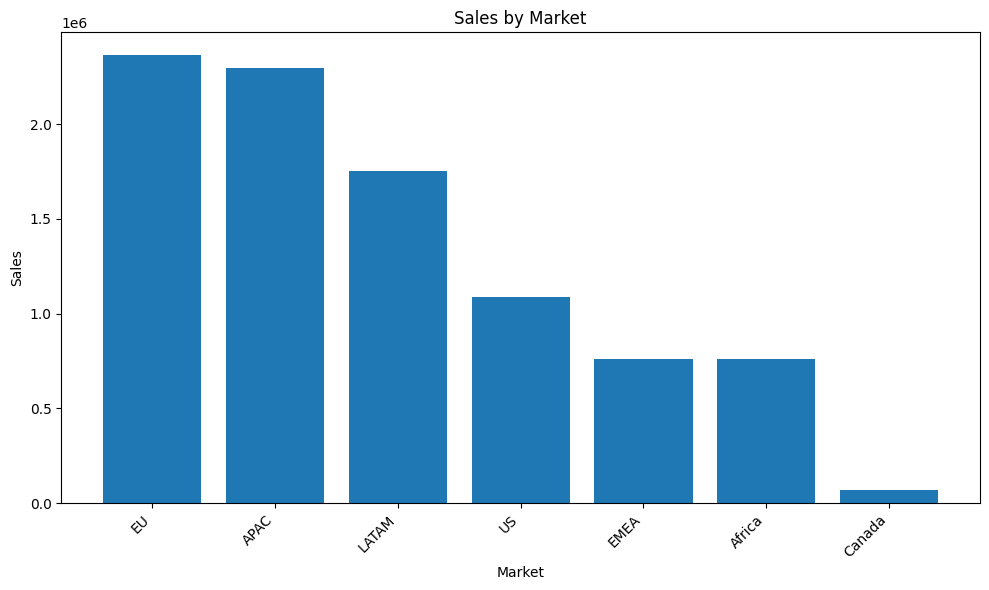

In [36]:
plot_bar(
    market_performance.sort_values("sales", ascending=False),
    x="market",
    y="sales",
    title="Sales by Market",
    xlabel="Market",
    ylabel="Sales"
)


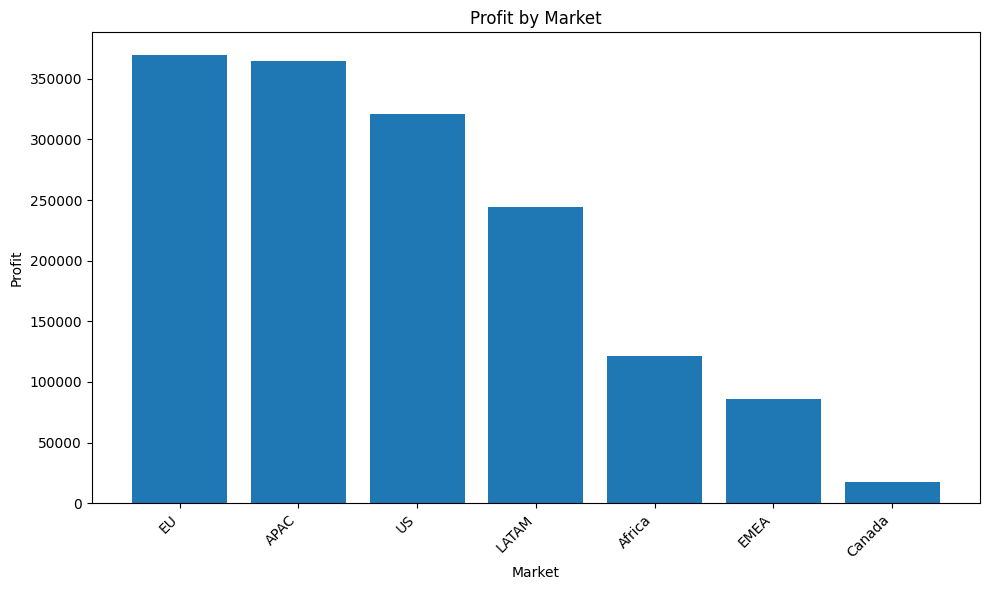

In [37]:
plot_bar(
    market_performance.sort_values("profit", ascending=False),
    x="market",
    y="profit",
    title="Profit by Market",
    xlabel="Market",
    ylabel="Profit"
)


In [38]:
region_performance = aggregate_performance(df, "region").sort_values("profit", ascending=False)
region_performance_display = region_performance.copy()
region_performance_display["sales"] = region_performance_display["sales"].map(format_currency)
region_performance_display["profit"] = region_performance_display["profit"].map(format_currency)
region_performance_display["profit_margin"] = region_performance_display["profit_margin"].map(format_percent)

region_performance_display


,region,sales,profit,quantity,orders,customers,profit_margin
3,Central,"$2,040,393","$333,853","30,488.00",3966,1707,16.36%
10,South,"$1,228,297","$192,819","19,362.00",2554,1480,15.70%
7,North,"$1,047,229","$187,894","15,645.00",2131,1210,17.94%
8,North Asia,"$809,213","$172,856","8,477.00",1099,600,21.36%
4,Central Asia,"$725,611","$140,319","7,350.00",973,552,19.34%
0,Africa,"$758,746","$121,688","9,670.00",2048,744,16.04%
6,East,"$341,781","$105,378","5,407.00",768,512,30.83%
5,EMEA,"$761,709","$85,832","10,228.00",2200,744,11.27%
12,West,"$287,063","$76,503","6,543.00",1071,579,26.65%
2,Caribbean,"$260,759","$38,361","5,084.00",692,460,14.71%


In [39]:
country_performance = aggregate_performance(df, ["market", "region", "country"])
country_performance = country_performance.sort_values("profit", ascending=False)

top_countries_by_profit = country_performance.head(10)
bottom_countries_by_profit = country_performance.sort_values("profit", ascending=True).head(10)

display(top_countries_by_profit)
display(bottom_countries_by_profit)


,market,region,country,sales,profit,quantity,orders,customers,profit_margin
6,APAC,North Asia,China,"684,595.00","152,381.21","7,003.00",915,546,0.22
2,APAC,Central Asia,India,"585,535.00","131,370.73","5,698.00",772,489,0.22
118,EU,North,United Kingdom,"494,261.00","110,149.48","5,640.00",718,497,0.22
147,US,East,United States,"341,781.00","105,377.55","5,407.00",768,512,0.31
110,EU,Central,Germany,"500,510.00","92,070.51","6,574.00",829,558,0.18
135,LATAM,North,Mexico,"477,194.00","87,327.70","8,714.00",1230,645,0.18
109,EU,Central,France,"591,315.00","81,895.68","8,846.00",1101,659,0.14
149,US,West,United States,"287,063.00","76,503.28","6,543.00",1071,579,0.27
146,US,Central,United States,"243,171.00","76,125.44","3,151.00",410,319,0.31
148,US,South,United States,"216,005.00","62,981.34","3,166.00",395,310,0.29


,market,region,country,sales,profit,quantity,orders,customers,profit_margin
101,EMEA,EMEA,Turkey,"67,651.00","-62,122.07","1,896.00",410,337,-0.92
51,Africa,Africa,Nigeria,"32,554.00","-49,000.28","1,229.00",247,217,-1.51
111,EU,Central,Netherlands,"47,255.00","-26,438.97","1,049.00",135,125,-0.56
132,LATAM,Central,Honduras,"53,964.00","-17,222.26","1,532.00",206,178,-0.32
4,APAC,Central Asia,Pakistan,"35,774.00","-16,907.15",643.00,83,80,-0.47
136,LATAM,South,Argentina,"38,181.00","-11,412.32",959.00,125,114,-0.30
117,EU,North,Sweden,"18,037.00","-10,594.27",427.00,60,57,-0.59
18,APAC,Southeast Asia,Philippines,"101,502.00","-8,999.91","1,422.00",185,162,-0.09
134,LATAM,Central,Panama,"26,222.00","-8,907.48",762.00,107,102,-0.34
88,EMEA,EMEA,Lithuania,"6,309.00","-8,294.70",129.00,20,20,-1.31


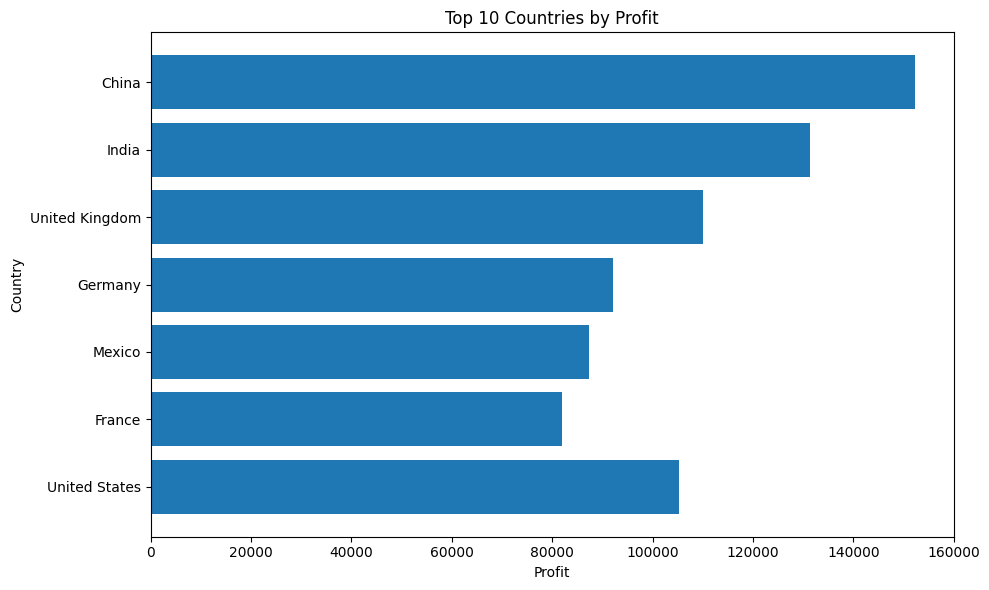

In [40]:
plot_horizontal_bar(
    top_countries_by_profit.sort_values("profit"),
    x="profit",
    y="country",
    title="Top 10 Countries by Profit",
    xlabel="Profit",
    ylabel="Country"
)


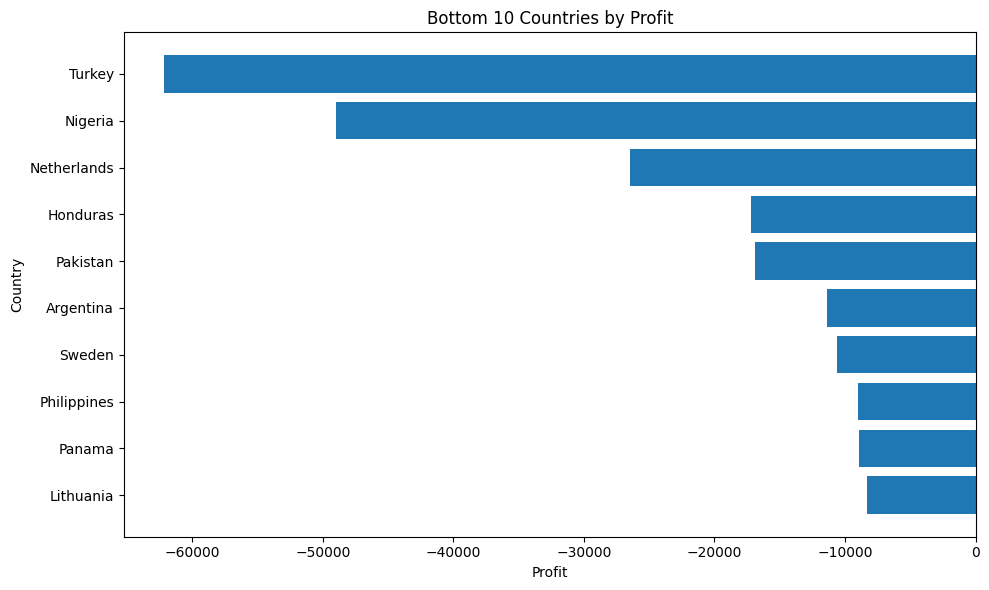

In [41]:
plot_horizontal_bar(
    bottom_countries_by_profit.sort_values("profit", ascending=False),
    x="profit",
    y="country",
    title="Bottom 10 Countries by Profit",
    xlabel="Profit",
    ylabel="Country"
)


### Observation Guide

Markets or countries with high sales but low profit margin may require strategic review.

The goal is to identify where growth is profitable and where growth may be hiding losses.


### Key Observation

**APAC**, **EU**, and **US** generate the highest total profit.

However, profitability varies significantly across markets and regions. **Canada** has the highest profit margin, but it represents a much smaller sales volume.

On the other hand, **EMEA** and **Southeast Asia** show weak profitability compared to other regions. These areas should be reviewed to understand whether the issue comes from discounts, product mix, or shipping costs.

## 10. Discount Impact Analysis

### Business Question

**Do discounts improve or reduce profitability?**

This section evaluates how discount levels affect sales, profit, and profit margin.


In [42]:
discount_order = [
    "No discount",
    "Low discount",
    "Moderate discount",
    "High discount",
    "Very high discount",
    "Extreme discount"
]

if "discount_band" not in df.columns:
    conditions = [
        df["discount"] == 0,
        (df["discount"] > 0) & (df["discount"] <= 0.10),
        (df["discount"] > 0.10) & (df["discount"] <= 0.20),
        (df["discount"] > 0.20) & (df["discount"] <= 0.30),
        (df["discount"] > 0.30) & (df["discount"] <= 0.50),
        df["discount"] > 0.50
    ]

    df["discount_band"] = np.select(
        conditions,
        discount_order,
        default="Unknown"
    )

discount_band_performance = aggregate_performance(df, "discount_band")
discount_band_performance["discount_band"] = pd.Categorical(
    discount_band_performance["discount_band"],
    categories=discount_order,
    ordered=True
)
discount_band_performance = discount_band_performance.sort_values("discount_band")

discount_band_performance_display = discount_band_performance.copy()
discount_band_performance_display["sales"] = discount_band_performance_display["sales"].map(format_currency)
discount_band_performance_display["profit"] = discount_band_performance_display["profit"].map(format_currency)
discount_band_performance_display["profit_margin"] = discount_band_performance_display["profit_margin"].map(format_percent)

discount_band_performance_display


,discount_band,sales,profit,quantity,orders,customers,profit_margin
4,No discount,"$6,992,734","$1,770,695","98,768.00",15211,4681,25.32%
2,Low discount,"$666,313","$112,068","5,239.00",1144,833,16.82%
3,Moderate discount,"$558,996","$50,157","5,699.00",1133,900,8.97%
1,High discount,"$134,651","$-4,840","1,548.00",344,303,-3.59%
5,Very high discount,"$543,566","$-190,928","12,100.00",1938,1330,-35.13%
0,Extreme discount,"$193,339","$-212,705","5,417.00",1058,894,-110.02%


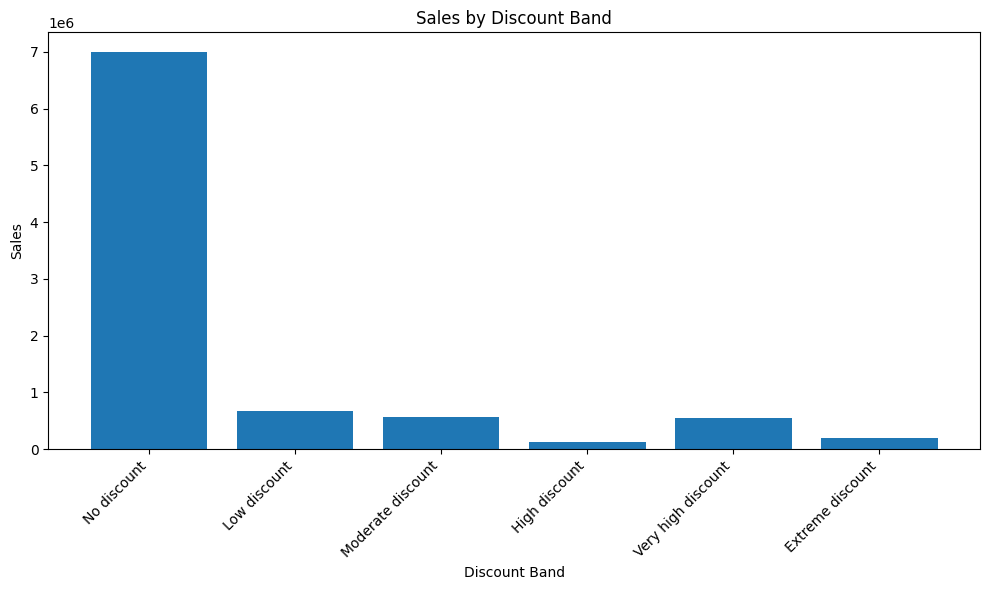

In [43]:
plot_bar(
    discount_band_performance,
    x="discount_band",
    y="sales",
    title="Sales by Discount Band",
    xlabel="Discount Band",
    ylabel="Sales"
)


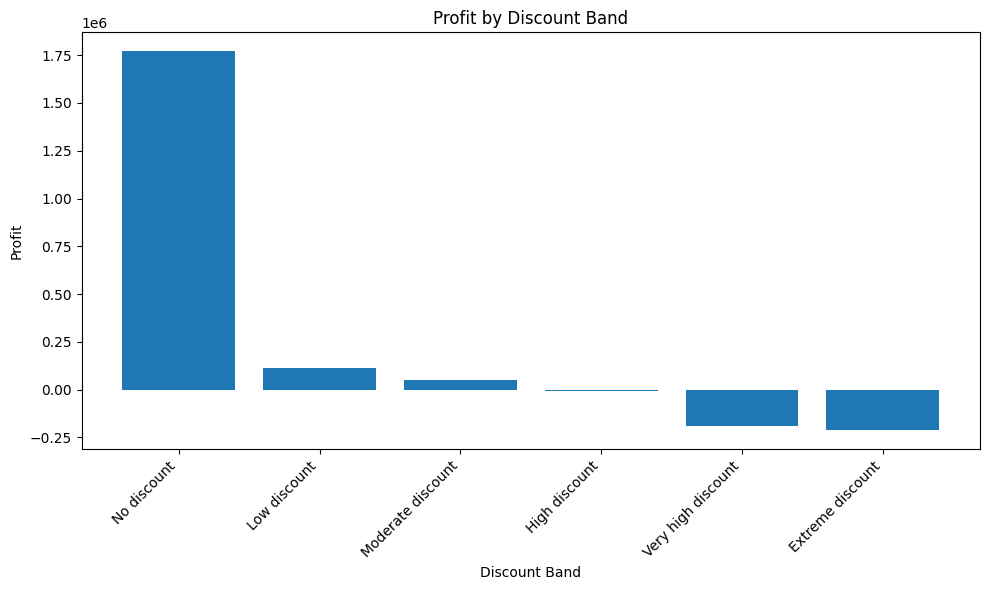

In [44]:
plot_bar(
    discount_band_performance,
    x="discount_band",
    y="profit",
    title="Profit by Discount Band",
    xlabel="Discount Band",
    ylabel="Profit"
)


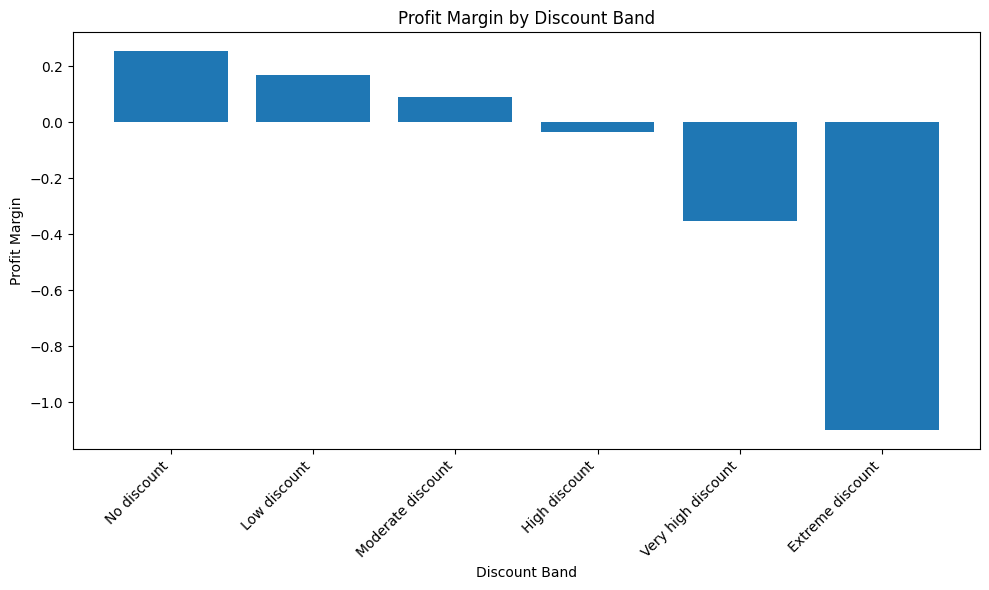

In [45]:
plot_bar(
    discount_band_performance,
    x="discount_band",
    y="profit_margin",
    title="Profit Margin by Discount Band",
    xlabel="Discount Band",
    ylabel="Profit Margin"
)


In [46]:
discount_value_performance = aggregate_performance(df, "discount").sort_values("discount")

discount_value_performance.head()


,discount,sales,profit,quantity,orders,customers,profit_margin
0,0.00,"6,992,734.00","1,770,695.27","98,768.00",15211,4681,0.25
1,0.00,"138,105.00","29,509.91",904.00,240,208,0.21
2,0.07,"71,011.00","11,398.33",320.00,82,79,0.16
3,0.10,"457,197.00","71,159.60","4,015.00",822,546,0.16
4,0.15,"170,938.00","16,154.87","1,056.00",250,226,0.09


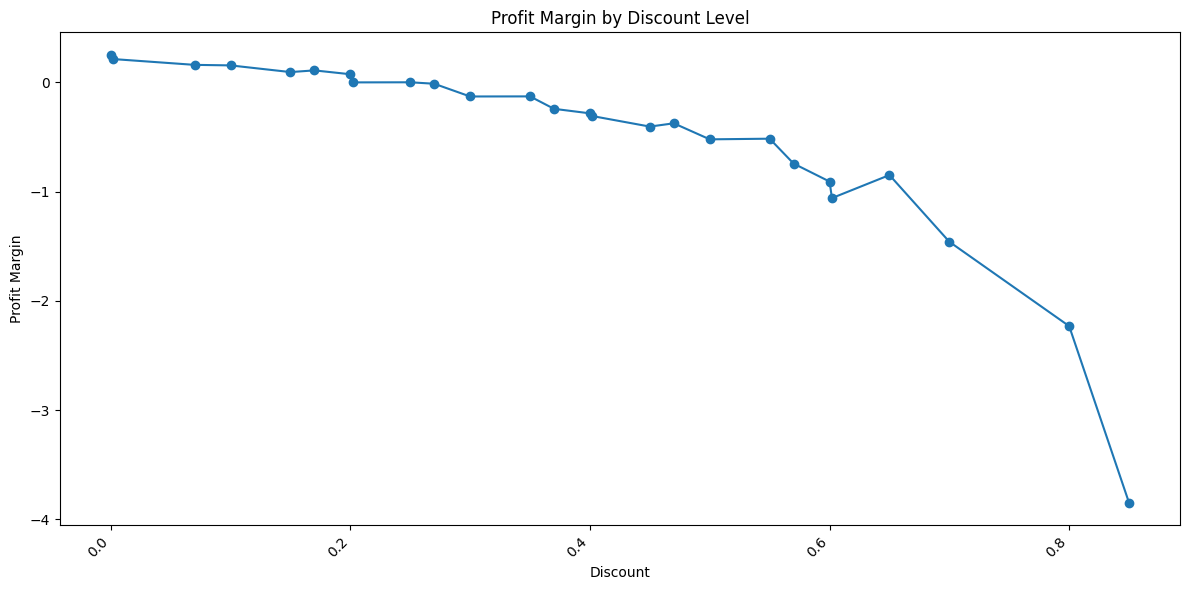

In [47]:
plot_line(
    discount_value_performance,
    x="discount",
    y="profit_margin",
    title="Profit Margin by Discount Level",
    xlabel="Discount",
    ylabel="Profit Margin"
)


In [48]:
loss_rate_by_discount_band = (
    df.groupby("discount_band")
    .agg(
        total_rows=("row_id", "count"),
        loss_making_rows=("profit", lambda x: (x < 0).sum())
    )
    .reset_index()
)

loss_rate_by_discount_band["loss_rate"] = (
    loss_rate_by_discount_band["loss_making_rows"] / loss_rate_by_discount_band["total_rows"]
)

loss_rate_by_discount_band["discount_band"] = pd.Categorical(
    loss_rate_by_discount_band["discount_band"],
    categories=discount_order,
    ordered=True
)

loss_rate_by_discount_band = loss_rate_by_discount_band.sort_values("discount_band")
loss_rate_by_discount_band["loss_rate_formatted"] = loss_rate_by_discount_band["loss_rate"].map(format_percent)

loss_rate_by_discount_band


,discount_band,total_rows,loss_making_rows,loss_rate,loss_rate_formatted
4,No discount,29009,0,0.00,0.00%
2,Low discount,1446,281,0.19,19.43%
3,Moderate discount,1491,523,0.35,35.08%
1,High discount,404,219,0.54,54.21%
5,Very high discount,3244,2870,0.88,88.47%
0,Extreme discount,2075,2075,1.00,100.00%


### Observation Guide

A discount strategy is useful only if it improves profitable sales.

If higher discount bands show lower profit margin or higher loss rate, discount policies may need to be reviewed.


### Key Observation

Discounts have a strong negative impact on profitability.

Transactions without discounts generate a profit margin of **25.32%**, while high discount levels produce negative margins.

From the **High discount** band onward, profit becomes negative:

- High discount: **-5.53%** profit margin
- Very high discount: **-32.39%** profit margin
- Extreme discount: **-111.02%** profit margin

This suggests that the current discount strategy should be reviewed carefully, especially for low-margin products and underperforming markets.

## 11. Shipping and Operational Analysis

### Business Question

**Do shipping costs and shipping methods affect profitability?**

This section analyzes shipping modes, shipping costs, delivery delays, and order priorities.


In [49]:
ship_mode_cost = df.groupby("ship_mode", as_index=False)["shipping_cost"].sum()
ship_mode_performance = aggregate_performance(df, "ship_mode").merge(ship_mode_cost, on="ship_mode", how="left")
ship_mode_performance = ship_mode_performance.sort_values("profit", ascending=False)
ship_mode_performance["shipping_cost_ratio"] = np.where(
    ship_mode_performance["sales"] != 0,
    ship_mode_performance["shipping_cost"] / ship_mode_performance["sales"],
    np.nan
)

ship_mode_performance_display = ship_mode_performance.copy()
ship_mode_performance_display["sales"] = ship_mode_performance_display["sales"].map(format_currency)
ship_mode_performance_display["profit"] = ship_mode_performance_display["profit"].map(format_currency)
ship_mode_performance_display["profit_margin"] = ship_mode_performance_display["profit_margin"].map(format_percent)
ship_mode_performance_display["shipping_cost"] = ship_mode_performance_display["shipping_cost"].map(format_currency)
ship_mode_performance_display["shipping_cost_ratio"] = ship_mode_performance_display["shipping_cost_ratio"].map(format_percent)

ship_mode_performance_display


,ship_mode,sales,profit,quantity,orders,customers,profit_margin,shipping_cost,shipping_cost_ratio
3,Standard Class,"$4,864,044","$980,516","69,511.00",10533,4236,20.16%,"$416,432",8.56%
2,Second Class,"$2,164,917","$277,919","30,002.00",4415,2818,12.84%,"$262,781",12.14%
0,First Class,"$1,514,823","$193,803","21,621.00",3251,2339,12.79%,"$256,933",16.96%
1,Same Day,"$545,815","$72,211","7,637.00",1137,996,13.23%,"$94,793",17.37%


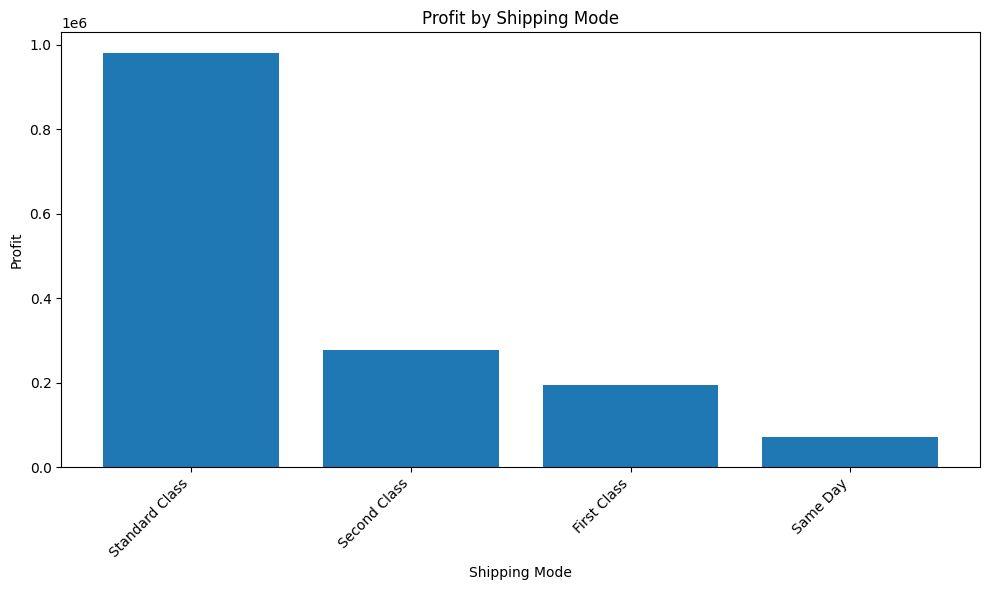

In [50]:
plot_bar(
    ship_mode_performance.sort_values("profit", ascending=False),
    x="ship_mode",
    y="profit",
    title="Profit by Shipping Mode",
    xlabel="Shipping Mode",
    ylabel="Profit"
)


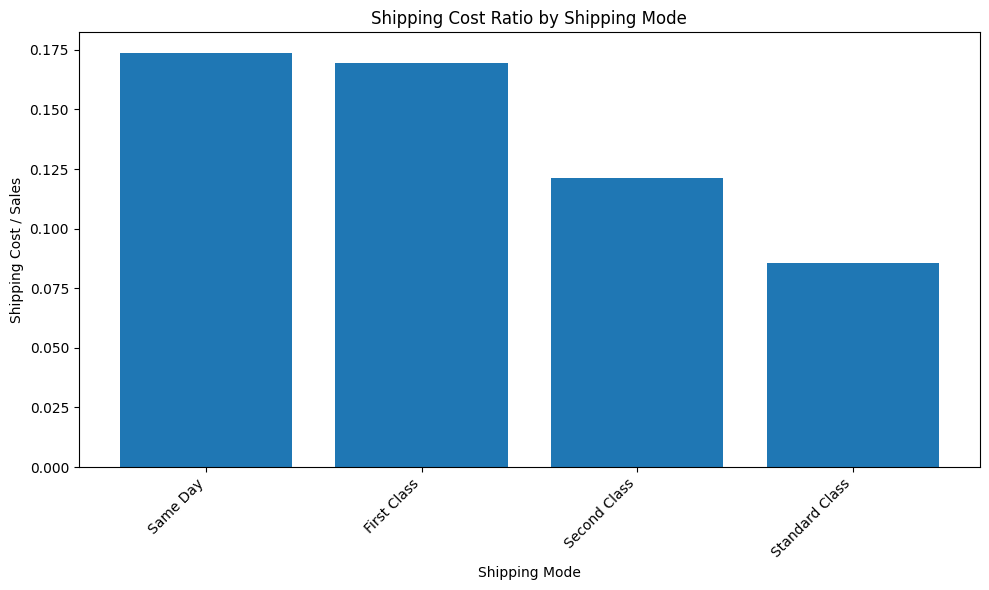

In [51]:
plot_bar(
    ship_mode_performance.sort_values("shipping_cost_ratio", ascending=False),
    x="ship_mode",
    y="shipping_cost_ratio",
    title="Shipping Cost Ratio by Shipping Mode",
    xlabel="Shipping Mode",
    ylabel="Shipping Cost / Sales"
)


,shipping_delay_days,sales,profit,quantity,orders,customers,profit_margin
0,0.00,"530,367.00","69,985.75","7,339.00",1090,962,0.13
1,1.00,"330,298.00","37,227.20","4,658.00",700,652,0.11
2,2.00,"1,514,437.00","194,337.78","20,485.00",3063,2238,0.13
3,3.00,"1,021,006.00","133,793.70","14,684.00",2184,1725,0.13
4,4.00,"2,486,889.00","447,677.97","34,921.00",5268,3174,0.18
5,5.00,"1,755,975.00","343,453.24","25,721.00",3945,2700,0.20
6,6.00,"956,019.00","197,895.04","13,776.00",2102,1676,0.21
7,7.00,"494,608.00","100,077.47","7,187.00",1106,977,0.20


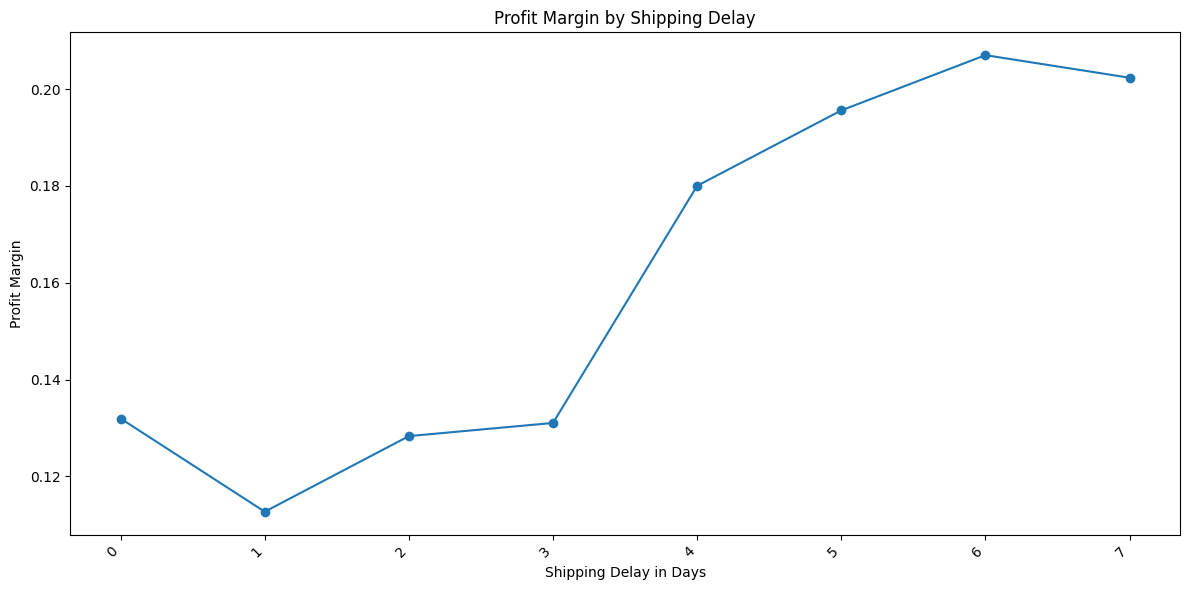

In [52]:
if "shipping_delay_days" in df.columns:
    shipping_delay_performance = aggregate_performance(df, "shipping_delay_days").sort_values("shipping_delay_days")
    display(shipping_delay_performance)

    plot_line(
        shipping_delay_performance,
        x="shipping_delay_days",
        y="profit_margin",
        title="Profit Margin by Shipping Delay",
        xlabel="Shipping Delay in Days",
        ylabel="Profit Margin"
    )
else:
    print("shipping_delay_days column not found.")


In [53]:
priority_performance = aggregate_performance(df, "order_priority").sort_values("profit", ascending=False)
priority_performance_display = priority_performance.copy()
priority_performance_display["sales"] = priority_performance_display["sales"].map(format_currency)
priority_performance_display["profit"] = priority_performance_display["profit"].map(format_currency)
priority_performance_display["profit_margin"] = priority_performance_display["profit_margin"].map(format_percent)

priority_performance_display


,order_priority,sales,profit,quantity,orders,customers,profit_margin
3,Medium,"$4,606,874","$951,194","65,643.00",9950,4164,20.65%
1,High,"$3,165,820","$394,077","44,790.00",6627,3537,12.45%
0,Critical,"$827,165","$116,145","11,285.00",1689,1399,14.04%
2,Low,"$489,740","$63,032","7,053.00",1049,915,12.87%


### Observation Guide

Shipping mode and order priority should be evaluated using both cost and profitability.

A faster or more expensive shipping method is not necessarily a problem if it supports profitable orders. However, if it increases cost without improving profit, it may need optimization.


### Key Observation

Shipping performance should be interpreted together with profitability.

A shipping method with a higher cost is not automatically bad if it supports profitable orders. However, if shipping costs increase faster than sales or profit, the company may need to optimize its logistics strategy.

This analysis will be useful for the future dashboard because shipping cost ratio, shipping delay, and order priority can help identify operational inefficiencies.

## 12. Preliminary Key Findings

This section automatically summarizes the main findings from the exploratory analysis.

These findings are preliminary and should be validated in the SQL analysis and final dashboard.


In [54]:
top_category = category_performance.sort_values("profit", ascending=False).iloc[0]
lowest_category = category_performance.sort_values("profit", ascending=True).iloc[0]
top_segment = segment_performance.sort_values("profit", ascending=False).iloc[0]
top_market = market_performance.sort_values("profit", ascending=False).iloc[0]
lowest_market = market_performance.sort_values("profit", ascending=True).iloc[0]
best_discount_band = discount_band_performance.sort_values("profit_margin", ascending=False).iloc[0]
worst_discount_band = discount_band_performance.sort_values("profit_margin", ascending=True).iloc[0]
best_ship_mode = ship_mode_performance.sort_values("profit_margin", ascending=False).iloc[0]

preliminary_findings = pd.DataFrame({
    "Business Area": [
        "Overall Profitability",
        "Product Category",
        "Product Category",
        "Customer Segment",
        "Market",
        "Market",
        "Discount Strategy",
        "Discount Strategy",
        "Shipping"
    ],
    "Finding": [
        f"Overall profit margin is {format_percent(profit_margin)}.",
        f"The most profitable category is {top_category['category']} with {format_currency(top_category['profit'])} in profit.",
        f"The least profitable category is {lowest_category['category']} with {format_currency(lowest_category['profit'])} in profit.",
        f"The most profitable customer segment is {top_segment['segment']} with {format_currency(top_segment['profit'])} in profit.",
        f"The most profitable market is {top_market['market']} with {format_currency(top_market['profit'])} in profit.",
        f"The least profitable market is {lowest_market['market']} with {format_currency(lowest_market['profit'])} in profit.",
        f"The discount band with the highest margin is {best_discount_band['discount_band']}.",
        f"The discount band with the lowest margin is {worst_discount_band['discount_band']}.",
        f"The shipping mode with the highest margin is {best_ship_mode['ship_mode']}.",
    ]
})

preliminary_findings


,Business Area,Finding
0,Overall Profitability,Overall profit margin is 16.77%.
1,Product Category,The most profitable category is Technology wit...
2,Product Category,The least profitable category is Furniture wit...
3,Customer Segment,The most profitable customer segment is Consum...
4,Market,"The most profitable market is EU with $369,797..."
5,Market,The least profitable market is Canada with $17...
6,Discount Strategy,The discount band with the highest margin is N...
7,Discount Strategy,The discount band with the lowest margin is Ex...
8,Shipping,The shipping mode with the highest margin is S...


## 13. Detailed Key EDA Findings

The exploratory analysis revealed several important insights that directly support the main business problem.

These findings are not final recommendations yet. They are the main clues that should be validated and deepened in the SQL analysis and later translated into Power BI dashboard pages.

In [55]:
eda_key_findings = pd.DataFrame({
    "Finding #": [1, 2, 3, 4, 5, 6, 7, 8],
    "Insight": [
        "Nova Retail is profitable overall, but 24.46% of order lines are loss-making.",
        "Sales increased strongly between 2011 and 2014, but profit did not always grow at the same pace.",
        "Discount levels have a major impact on profitability.",
        "High, very high, and extreme discounts generate negative profit margins.",
        "Tables are the main loss-making sub-category despite generating significant sales.",
        "Consumer generates the largest total profit, while Home Office has the highest profit margin.",
        "APAC, EU, and US are the most profitable markets by total profit.",
        "EMEA and Southeast Asia show weak profitability and should be investigated further."
    ],
    "Business Meaning": [
        "The company should not focus only on total revenue. It must identify where losses are created.",
        "Growth is positive, but profitable growth requires controlling margin erosion.",
        "Discount policy is likely one of the main levers affecting profit.",
        "Aggressive discounts may increase sales but destroy profitability.",
        "High sales volume does not guarantee business value.",
        "Customer segments should be evaluated using both volume and margin.",
        "These markets may deserve continued investment.",
        "These regions may require review of product mix, discounts, or operating costs."
    ]
})

eda_key_findings

,Finding #,Insight,Business Meaning
0,1,"Nova Retail is profitable overall, but 24.46% ...",The company should not focus only on total rev...
1,2,Sales increased strongly between 2011 and 2014...,"Growth is positive, but profitable growth requ..."
2,3,Discount levels have a major impact on profita...,Discount policy is likely one of the main leve...
3,4,"High, very high, and extreme discounts generat...",Aggressive discounts may increase sales but de...
4,5,Tables are the main loss-making sub-category d...,High sales volume does not guarantee business ...
5,6,"Consumer generates the largest total profit, w...",Customer segments should be evaluated using bo...
6,7,"APAC, EU, and US are the most profitable marke...",These markets may deserve continued investment.
7,8,EMEA and Southeast Asia show weak profitabilit...,These regions may require review of product mi...


## 14. Transition to SQL Analysis

The EDA helped identify the main business areas requiring deeper investigation.

The next step is to validate these findings using SQL queries. SQL will be used to reproduce key business metrics and answer business questions in a structured and reusable way.

The SQL phase will focus on:

- overall KPI validation;
- yearly and monthly sales/profit trends;
- product and sub-category profitability;
- high-sales but low-margin products;
- customer and segment performance;
- market, region, and country performance;
- discount impact analysis;
- shipping and operational performance;
- ranking, running totals, and year-over-year growth.

This will demonstrate that the analysis can be performed not only in Python, but also with SQL in a business database environment.

## 15. Export EDA Summary Tables

The main summary tables are exported so they can be reused later in the report, dashboard planning, or README documentation.


In [56]:
possible_output_dirs = [
    Path("../reports/eda_outputs"),
    Path("reports/eda_outputs"),
    Path("eda_outputs")
]

OUTPUT_DIR = possible_output_dirs[0]

if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = possible_output_dirs[1]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

exports = {
    "kpi_summary.csv": kpi_summary,
    "yearly_performance.csv": yearly_performance,
    "monthly_performance.csv": monthly_performance,
    "category_performance.csv": category_performance,
    "sub_category_performance.csv": sub_category_performance,
    "product_performance.csv": product_performance,
    "segment_performance.csv": segment_performance,
    "customer_performance.csv": customer_performance,
    "market_performance.csv": market_performance,
    "region_performance.csv": region_performance,
    "country_performance.csv": country_performance,
    "discount_band_performance.csv": discount_band_performance,
    "ship_mode_performance.csv": ship_mode_performance,
    "priority_performance.csv": priority_performance,
    "preliminary_findings.csv": preliminary_findings,
    "eda_key_findings.csv": eda_key_findings,
    "product_identity_check.csv": product_identity_check
}

for filename, table in exports.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

print(f"EDA summary tables exported to: {OUTPUT_DIR}")


EDA summary tables exported to: reports/eda_outputs


## 16. Conclusion

This exploratory analysis provides an initial view of Nova Retail's business performance across sales, profit, products, customers, markets, discounts, and shipping.

The analysis confirms that revenue and profitability are not always aligned. Nova Retail is profitable overall, but a significant share of order lines generates losses.

The strongest preliminary insight is the negative relationship between high discount levels and profitability. From the high discount band onward, profit margins become negative.

The analysis also highlights several areas requiring deeper investigation:

- products with high sales but low profit margin;
- loss-making products and sub-categories, especially Tables;
- customer segments with different profitability profiles;
- markets and regions with weak profit performance;
- discount levels that reduce margin;
- shipping modes with high cost relative to sales.

The next step will be to validate and deepen these insights using SQL business analysis.
